In [14]:
import gmsh
import sys
import math
from femppp import *

In [15]:

L = 6.0
H = 1.0
R = 0.63
lc = 0.08
mesh_file = "barra_protuberancia.msh"

gmsh.initialize()
gmsh.model.add("barra_con_protuberancia")

# ==========================================================
# 1. Barra rectangular
# ==========================================================
rect = gmsh.model.occ.addRectangle(0.0, 0.0, 0.0, L, H)

# ==========================================================
# 2. Círculo centrado
# ==========================================================
xc = L / 2.0
yc = H / 2.0
circle = gmsh.model.occ.addDisk(xc, yc, 0.0, R, R)

# ==========================================================
# 3. Unión booleana
# ==========================================================
fused, _ = gmsh.model.occ.fuse([(2, rect)], [(2, circle)])

gmsh.model.occ.synchronize()

# ==========================================================
# 4. Identificación de bordes izquierdo y derecho
# ==========================================================
tol = 1e-6

left_curves = []
right_curves = []

curves = gmsh.model.getEntities(dim=1)

for dim, tag in curves:
    xmin, ymin, zmin, xmax, ymax, zmax = \
        gmsh.model.getBoundingBox(dim, tag)

    # Borde izquierdo
    if abs(xmin) < tol and abs(xmax) < tol:
        left_curves.append(tag)

    # Borde derecho
    if abs(xmin - L) < tol and abs(xmax - L) < tol:
        right_curves.append(tag)

# ==========================================================
# 5. Physical Groups
# ==========================================================
domain_surfaces = gmsh.model.getEntities(dim=2)

gmsh.model.addPhysicalGroup(2,
    [s[1] for s in domain_surfaces], name="Domain")

if left_curves:
    gmsh.model.addPhysicalGroup(1, left_curves, name="Left")

if right_curves:
    gmsh.model.addPhysicalGroup(1, right_curves, name="Right")

# ==========================================================
# 6. Tamaño de malla
# ==========================================================
gmsh.option.setNumber("Mesh.CharacteristicLengthMin", lc)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", lc)

# Forzar triángulos
gmsh.option.setNumber("Mesh.RecombineAll", 0)

# ==========================================================
# 7. Generar malla 2D
# ==========================================================
gmsh.model.mesh.generate(2)

gmsh.write(mesh_file)

print(f"Malla guardada como: {mesh_file}")

gmsh.finalize()

Malla guardada como: barra_protuberancia.msh


In [16]:
nodes, tris, boundary_nodes, boundary_edges = read_msh_extract_data("barra_protuberancia.msh", gmsh)

In [17]:
boundary_nodes

{'Left': array([ 0,  1,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),
 'Right': array([  4,   5,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
        105])}

In [18]:
t = 1.          # espesor [m]
E = 200e9         # módulo de Young [Pa]
nu = 0.3          # coeficiente de Poisson
rho = 10000.0      # densidad [kg/m^3]
g = 9.81          # gravedad [m/s^2]

# Carga de volumen (gravedad)
bx = 0.0
by = -rho * g     # [N/m^3]

In [19]:
# ------------------------------------------------------------
# Crear objetos de elemento finito (CST)
# ------------------------------------------------------------
elements = []
for tri in tris:
    elem = TriangularElement(
        node_ids=tri,
        nodes=nodes,
        E=E,
        nu=nu,
        thickness=t,
        element_type="CST"
    )
    elements.append(elem)

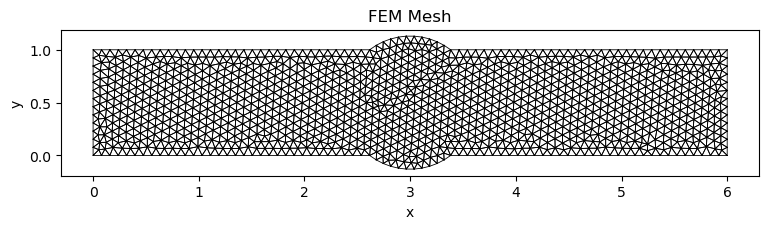

In [20]:
# ------------------------------------------------------------
# Construir el problema y aplicar condiciones
# ------------------------------------------------------------
problem = FEMProblem(elements)
problem.assemble_stiffness()

problem.plot_mesh(show_nodes=False,
        show_node_ids=False,
        show_elements=True,
        show_element_ids=False,
        element_ids_size=9,
        node_ids_size=9,
        figure_size=(9, 3),
        line_color="k",
        line_width=0.6,
        node_color="r",
        node_size=30,)

In [21]:
# Empotramiento en x = 0
left_nodes = boundary_nodes["Left"]
dirichlet_values = np.zeros((len(left_nodes), 2))
problem.apply_dirichlet_bcs(nodes=left_nodes, values=dirichlet_values)

# Carga distribuida en x = L (vertical hacia abajo)
right_nodes = boundary_nodes["Right"]
dirichlet_values = np.zeros((len(right_nodes), 2))
problem.apply_dirichlet_bcs(nodes=right_nodes, values=dirichlet_values)

# Carga de cuerpo: gravedad
problem.apply_body_force(bx, by)

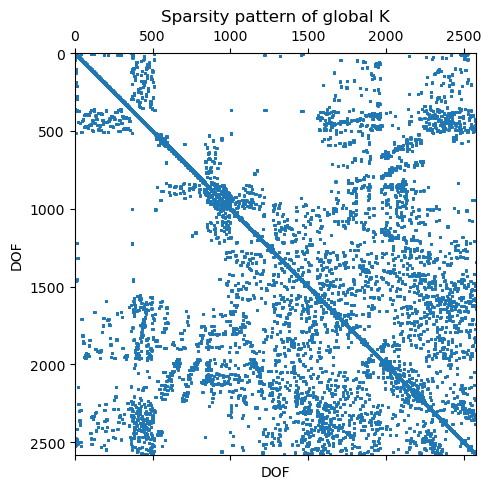

In [22]:
problem.plot_stiffness_sparsity(figsize=(5,5))

In [23]:
# ------------------------------------------------------------
# Resolver
# ------------------------------------------------------------
problem.solve(method="cg", tol=1e-10)
problem.compute_element_stresses()   # calcula tensiones en cada elemento


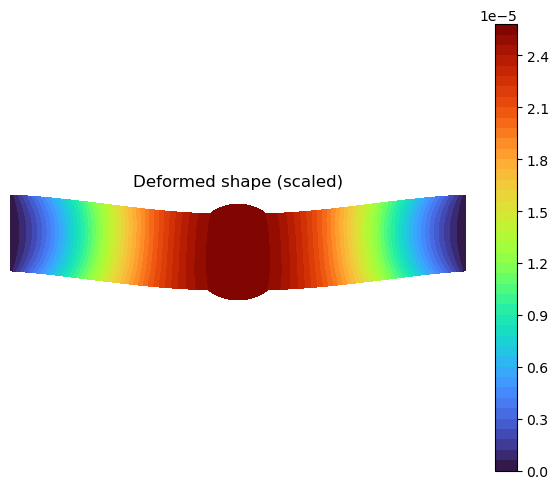

In [24]:
# Contorno deformado (escala 50x)
plot_deformed_contour(
    nodes,
    tris,
    problem.ux,
    problem.uy,
    scale = 10000,
)

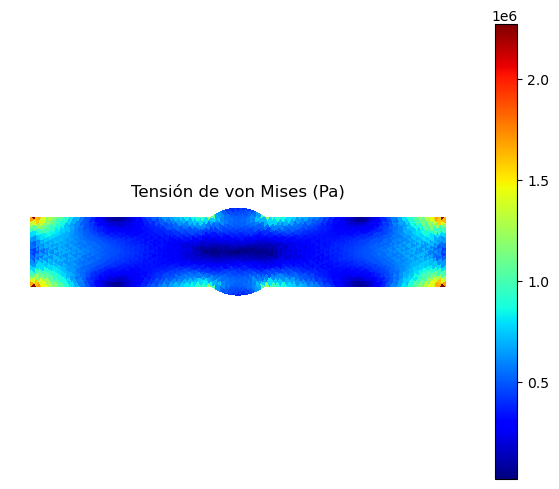

In [25]:
# Tensión de von Mises por elemento
problem.plot_elemental_variable(
    nodes,
    tris,
    problem.sigma_vm,
    title="Tensión de von Mises (Pa)"
)